# The low season and the parks
**Gorilla permits and park visits, January–June 2022–2026:** Ministry of Tourism, Wildlife and Antiquities, Tourism Statistics January–June 2026. Its 2022–2024 figures agree exactly with the Statistical Abstract 2025 (checked in `scripts/extract_tables.py`).
**The discount:** on 26 February 2026 the Uganda Wildlife Authority cut the foreign non-resident gorilla permit from US$800 to US$600 for April, May and November, as reported by several tour operators; it is not yet in a published tariff. A similar discount ran from 2011 to November 2017, but no monthly permit data for those years are published.

**Questions**
1. Did gorilla permit sales rise more in the discounted months (April and May 2026) than in the full-price months?
2. How large would the rise need to be for the discount to pay for itself?
3. Which parks are growing, and what happened in the first half of 2026?

In [1]:
import sys, warnings
sys.path.insert(0, '../scripts')
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from tourism import (PROC, MON, GORILLA_PERMIT_USD, EAST_AFRICA, load_parks_annual, load_parks_monthly, load_parks_category,
                     load_arrivals_purpose, load_arrivals_monthly, load_arrivals_country, load_arrivals_region,
                     load_overseas_markets, load_gorilla, load_chimp,
                     load_hotels, load_untourism, load_rainfall, load_h1_gorilla, load_h1_parks, DISCOUNT)

INK, GREY, LIGHT, GRID = '#1a1a1a', '#6b6b6b', '#b5b3ad', '#e6e4df'
WET, DRY, GREEN = '#2b6c9e', '#c4572e', '#3d8b5f'
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10, 'axes.titlesize': 12, 'axes.titleweight': 'medium',
    'axes.titlelocation': 'left', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9c8c4', 'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'xtick.color': GREY, 'ytick.color': GREY, 'axes.labelcolor': GREY,
    'legend.frameon': False,
})
pd.set_option('display.width', 200)

## 1. The first discounted season
Permits available in April and May are almost identical in 2025 and 2026 (5,880 and 5,888; 6,076 and 6,084), so sales can be compared directly. The test compares growth in the discounted months (April–May) with growth in the full-price months before them (January–March), and checks how big that gap is in years without a discount. June is left out: park visits fell sharply in June 2026 for reasons unrelated to permit prices (section 3).

In [2]:
hg = load_h1_gorilla()
sold = hg.pivot_table(index='year', columns='month', values='sold')
avail = hg.pivot_table(index='year', columns='month', values='available')
print('Gorilla permits sold, January–June:'); print(sold.astype(int).to_string())
print('\nShare sold (%):'); print((100 * sold / avail).round(0).astype(int).to_string())

rows = []
for y0, y1 in [(2023, 2024), (2024, 2025), (2025, 2026)]:
    d = sold.loc[y1, [4, 5]].sum() / sold.loc[y0, [4, 5]].sum() - 1
    f = sold.loc[y1, [1, 2, 3]].sum() / sold.loc[y0, [1, 2, 3]].sum() - 1
    du = (sold.loc[y1, [4, 5]].sum() / avail.loc[y1, [4, 5]].sum()) - (sold.loc[y0, [4, 5]].sum() / avail.loc[y0, [4, 5]].sum())
    fu = (sold.loc[y1, [1, 2, 3]].sum() / avail.loc[y1, [1, 2, 3]].sum()) - (sold.loc[y0, [1, 2, 3]].sum() / avail.loc[y0, [1, 2, 3]].sum())
    rows.append({'years': f'{y0}→{y1}', 'discount in Apr–May': y1 == 2026,
                 'Apr–May sales growth %': 100 * d, 'Jan–Mar sales growth %': 100 * f, 'gap, points': 100 * (d - f),
                 'Apr–May share sold, change (points)': 100 * du, 'Jan–Mar share sold, change (points)': 100 * fu})
test = pd.DataFrame(rows)
print('\n'); print(test.round(1).to_string(index=False))

Gorilla permits sold, January–June:
month     1     2     3     4     5     6
year                                     
2022    370  1120   681   273   384  1600
2023   2860  3045  1558  1248  1612  3616
2024   3952  4351  2077  1155  1655  4115
2025   4531  3953  1963  1177  1786  4546
2026   4491  4442  2022  1339  1896  3516

Share sold (%):
month   1   2   3   4   5   6
year                         
2022    8  26  14   6   8  35
2023   59  70  32  27  34  79
2024   66  78  35  20  27  70
2025   75  72  32  20  29  77
2026   74  81  33  23  31  60


    years  discount in Apr–May  Apr–May sales growth %  Jan–Mar sales growth %  gap, points  Apr–May share sold, change (points)  Jan–Mar share sold, change (points)
2023→2024                False                    -1.7                    39.1        -40.8                                 -7.3                                  6.3
2024→2025                False                     5.4                     0.6          4.8                  

Break-even: at US$600 instead of US$800, sales must rise 33% for permit revenue to stay level
April–May 2026: 3,235 permits sold; 3,107 expected from the January–March trend; extra +128 (+4%)
If every April–May permit was sold at the discounted price, permit revenue was US$1.94 million against US$2.49 million expected at full price: a change of US$-0.54 million. This is the largest possible loss; the true figure is smaller, since some buyers pay East African or rest-of-Africa rates


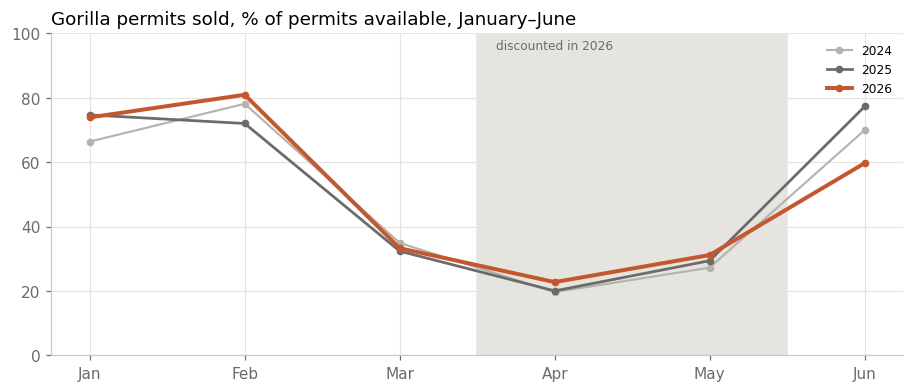

In [3]:
full, disc = DISCOUNT['full_price'], DISCOUNT['price']
need = full / disc - 1
am25, am26 = sold.loc[2025, [4, 5]].sum(), sold.loc[2026, [4, 5]].sum()
trend = sold.loc[2026, [1, 2, 3]].sum() / sold.loc[2025, [1, 2, 3]].sum()
counter = am25 * trend                      # April–May 2026 sales had they grown like January–March
extra = am26 - counter
print(f"Break-even: at US${disc} instead of US${full}, sales must rise {100 * need:.0f}% for permit revenue to stay level")
print(f"April–May 2026: {am26:,.0f} permits sold; {counter:,.0f} expected from the January–March trend; extra {extra:+,.0f} ({100 * extra / counter:+.0f}%)")
print(f"If every April–May permit was sold at the discounted price, permit revenue was US${am26 * disc / 1e6:.2f} million "
      f"against US${counter * full / 1e6:.2f} million expected at full price: a change of US${(am26 * disc - counter * full) / 1e6:+.2f} million. "
      f"This is the largest possible loss; the true figure is smaller, since some buyers pay East African or rest-of-Africa rates")

fig, ax = plt.subplots(figsize=(10, 3.8))
MN = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
for y, col, lw in [(2024, LIGHT, 1.4), (2025, GREY, 1.8), (2026, DRY, 2.6)]:
    ax.plot(MN, 100 * sold.loc[y] / avail.loc[y], marker='o', ms=4, lw=lw, color=col, label=str(y))
ax.axvspan(2.5, 4.5, color=GRID, zorder=0); ax.text(3, 95, 'discounted in 2026', ha='center', fontsize=8, color=GREY)
ax.set_ylim(0, 100); ax.set_title('Gorilla permits sold, % of permits available, January–June'); ax.legend(fontsize=8); plt.show()

**No sign yet that the discount filled the low season.** Sales in April–May 2026 grew 9% on 2025, against 5% in January–March: a gap of about 4 points. But in 2025, with no discount, April–May also outgrew January–March by about 5 points, and measured as the share of permits sold, the discounted months improved slightly less than the full-price months (+2.2 against +2.8 points). April–May 2026 sold about 128 permits (4%) more than the January–March trend implies. For the discount to pay for itself, sales would need to rise a third. At most, if every permit in those months sold at the discounted price, permit revenue fell by about US$0.5 million.

This is a first and early read. The discount was announced about five weeks before April, while gorilla trips are often booked months ahead, and operators report that only part of the permits are released at the lower price. November 2026 and the 2027 low season will be the real test. Overall park visits fell 11% in April–May 2026 while gorilla permit sales rose.

## 2. Parks

In [4]:
hp, hb = load_h1_parks()
pa = load_parks_annual()
by = pa.pivot_table(index='park', columns='year', values='visits')
g = pd.DataFrame({'2019': by[2019], '2024': by[2024], 'change 2019–2024 %': 100 * (by[2024] / by[2019] - 1)}).dropna()
print('Visits by park, 2019 and 2024:'); print(g.sort_values('2024', ascending=False).round(0).to_string())

hb.index = hb.index.str.replace(' Wildlife Reserve', ' WR').str.replace('-Wildlife Reserve', ' WR')
hb['change %'] = 100 * (hb['2026'] / hb['2025'] - 1)
print('\nVisits by park, January–June 2025 and 2026:'); print(hb.sort_values('2025', ascending=False).round(1).to_string())
tot25, tot26 = hb['2025'].sum(), hb['2026'].sum()
qe = 'Queen Elizabeth'
print(f"\nAll parks: {100 * (tot26 / tot25 - 1):+.1f}%; without Queen Elizabeth: {100 * ((tot26 - hb.loc[qe, '2026']) / (tot25 - hb.loc[qe, '2025']) - 1):+.1f}%")
pm = hp.pivot_table(index='year', columns='month', values='visits')
print('\nAll parks by month, % change 2025→2026:', (100 * (pm.loc[2026] / pm.loc[2025] - 1)).round(0).astype(int).to_dict())

Visits by park, 2019 and 2024:
                                   2019      2024  change 2019–2024 %
park                                                                 
Murchison Falls                103665.0  139304.0                34.0
Queen Elizabeth                 77995.0  124645.0                60.0
Lake Mburo                      33188.0   44043.0                33.0
Bwindi Impenetrable             36341.0   43364.0                19.0
Semliki                         22577.0   42545.0                88.0
Kibale                          19521.0   19748.0                 1.0
Kidepo Valley                   12648.0    7613.0               -40.0
Mgahinga Gorilla                 7593.0    7362.0                -3.0
Rwenzori Mountains               6043.0    4835.0               -20.0
Mount Elgon                      3519.0    1354.0               -62.0
Toro Semliki Wildlife Reserve     771.0     290.0               -62.0

Visits by park, January–June 2025 and 2026:
              

**Growth since 2019 is uneven.** Semliki (+88%), Queen Elizabeth (+60%), Murchison Falls (+34%) and Lake Mburo (+33%) grew; Kibale and Mgahinga stood still; Kidepo Valley (−40%), Rwenzori Mountains (−20%) and Mount Elgon (−62%) shrank. The remote north-eastern and mountain parks are losing ground while the most-visited parks grow.

**The first half of 2026 fell 8%, entirely at Queen Elizabeth.** Its visits dropped 40% on January–June 2025, from about 54,000 to 33,000, while all other parks together grew 5%; the fall deepened from April (all parks −11% in April and May, −26% in June). The source does not give a reason.

In [5]:
test.round(2).to_csv(PROC / 'discount_test.csv', index=False)
hb.round(2).to_csv(PROC / 'parks_h1_change.csv')
g.round(1).to_csv(PROC / 'parks_change_2019_2024.csv')
print('saved')

saved
